# 05. Evaluation and Error Analysis

**Course:** CSE437 Data Science
**Group:** 15
**Project:** Predicting Google Play Store App Ratings Using Machine Learning

**Purpose of this notebook.** Model selection and hyperparameter tuning are
already finished (`04_modeling_and_tuning.ipynb`), using cross-validation on the
training set only. This notebook loads the three **already-fitted, final** models
(`Dummy`, tuned `Ridge`, tuned `RandomForest`) and:

1. Reports test-set R², MAE, RMSE for all three (the same headline numbers
   established once in notebook 04 — reproduced here from the saved models purely
   to generate the per-row predictions needed for diagnostic plots and error
   analysis, not to re-select or re-tune anything).
2. Produces predicted-vs-actual, residual, and error-distribution plots.
3. Extracts RandomForest feature importances and a Ridge coefficient
   visualisation.
4. Runs a detailed error analysis across review count, install count,
   paid/free, category, and rating-level subgroups.
5. Presents at least two concrete badly-predicted examples with evidence-based
   explanations.
6. Answers the three approved research questions directly, using the evidence
   gathered across all five notebooks.
7. Interprets the R² honestly against the faculty's expected 0.05–0.15 range.


## 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

FEATURES_PATH = "../data/processed/googleplaystore_features.csv"
SPLIT_PATH = "../data/processed/train_test_split.csv"
MODELS_DIR = "../models"
FIGURES_DIR = "../figures"
PROCESSED_DIR = "../data/processed"

print("Random seed fixed at:", RANDOM_STATE)


Random seed fixed at: 42


## 1. Load Final Models and the Untouched Test Set

The three models saved at the end of `04_modeling_and_tuning.ipynb` are loaded
as-is — nothing is refit or retuned here. The test split is reconstructed from
the same saved `train_test_split.csv` used throughout the project.


In [2]:
df = pd.read_csv(FEATURES_PATH)
split = pd.read_csv(SPLIT_PATH)

numeric_features = ["log_reviews", "log_installs", "Size_MB", "Price_USD", "is_paid", "days_since_update"]
categorical_features = ["Category", "Content Rating"]
feature_columns = numeric_features + categorical_features
target = "Rating"

test_idx = split.loc[split["split"] == "test", "row_index"].values
X_test = df.loc[test_idx, feature_columns]
y_test = df.loc[test_idx, target]

# Keep a metadata copy (App name, raw features) alongside predictions for the
# error analysis in Section 5.
meta_test = df.loc[test_idx].copy()

dummy_model = joblib.load(f"{MODELS_DIR}/dummy_baseline.joblib")
ridge_model = joblib.load(f"{MODELS_DIR}/ridge_tuned.joblib")
rf_model = joblib.load(f"{MODELS_DIR}/random_forest_tuned.joblib")

print(f"Test set: {X_test.shape[0]} rows")
print("Loaded: dummy_baseline.joblib, ridge_tuned.joblib, random_forest_tuned.joblib")


Test set: 1640 rows
Loaded: dummy_baseline.joblib, ridge_tuned.joblib, random_forest_tuned.joblib


## 2. Test-Set Performance — Dummy vs. Ridge (tuned) vs. RandomForest (tuned)

**Primary metric (declared in `04_modeling_and_tuning.ipynb`, before any test
result was seen): R².** MAE and RMSE are reported as secondary metrics in
rating-point units.


In [3]:
meta_test["pred_dummy"] = dummy_model.predict(X_test)
meta_test["pred_ridge"] = ridge_model.predict(X_test)
meta_test["pred_rf"] = rf_model.predict(X_test)

results = []
for name, col in [("Dummy (baseline)", "pred_dummy"),
                   ("Ridge (tuned)", "pred_ridge"),
                   ("RandomForest (tuned)", "pred_rf")]:
    y_pred = meta_test[col]
    results.append({
        "model": name,
        "test_r2": r2_score(y_test, y_pred),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    })

final_results_table = pd.DataFrame(results)
final_results_table.to_csv(f"{PROCESSED_DIR}/final_evaluation_results.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/final_evaluation_results.csv")
final_results_table


Saved: ../data/processed/final_evaluation_results.csv


,model,test_r2,test_mae,test_rmse
0,Dummy (baseline),-0.000008,0.383343,0.545597
1,Ridge (tuned),0.139751,0.344691,0.506037
2,RandomForest (tuned),0.163612,0.338119,0.498970


**Reading this table.** Both trained models clearly outperform the Dummy
baseline. RandomForest edges out Ridge on all three metrics on this particular
test split, though the two are close enough (and the CV standard deviations
reported in notebook 04 overlap enough) that this should be read as "both
model families extract a similar, modest amount of real signal," not as RF being
decisively superior. Full interpretation is in Section 6.


## 3. Predicted vs. Actual, Residuals, and Error Distribution


In [4]:
meta_test["error_ridge"] = meta_test["Rating"] - meta_test["pred_ridge"]
meta_test["error_rf"] = meta_test["Rating"] - meta_test["pred_rf"]
meta_test["abs_err_ridge"] = meta_test["error_ridge"].abs()
meta_test["abs_err_rf"] = meta_test["error_rf"].abs()


### 3.1 Predicted vs. Actual

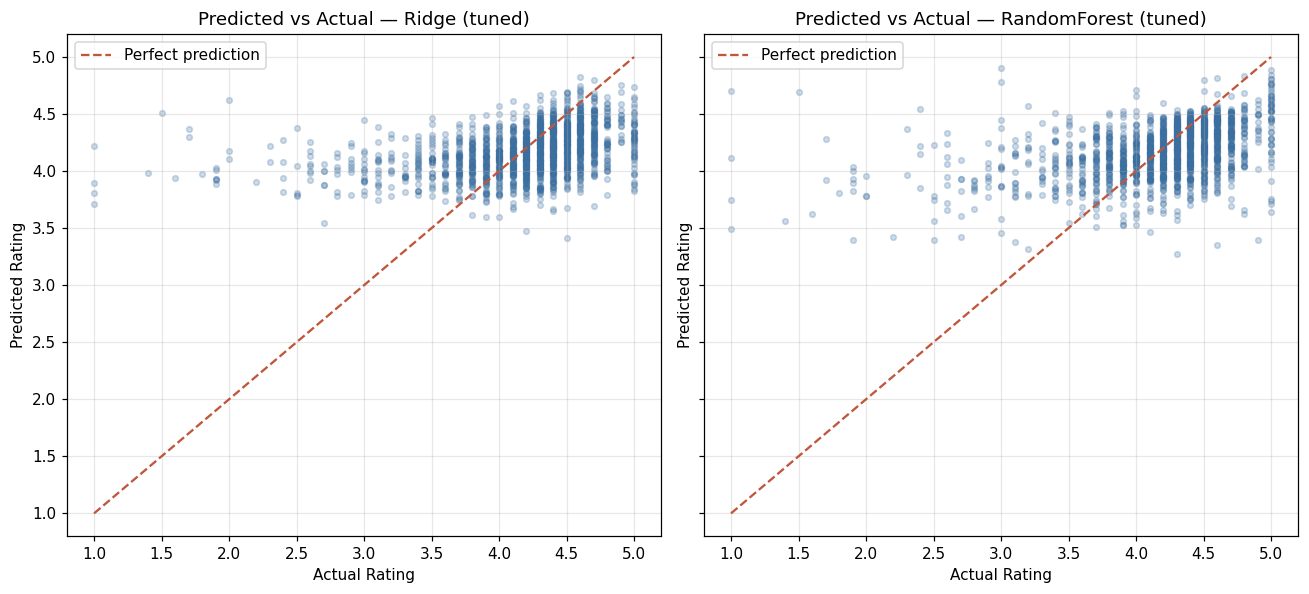

Saved: ../figures/11_predicted_vs_actual.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)

for ax, col, name in zip(axes, ["pred_ridge", "pred_rf"], ["Ridge (tuned)", "RandomForest (tuned)"]):
    ax.scatter(meta_test["Rating"], meta_test[col], alpha=0.25, s=14, color="#3b6fa0")
    ax.plot([1, 5], [1, 5], color="#c0563b", linestyle="--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(f"Predicted vs Actual — {name}")
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(0.8, 5.2)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/11_predicted_vs_actual.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/11_predicted_vs_actual.png")


**Observation.** Both models' predictions cluster tightly in a narrow
vertical band around ~3.8–4.5, regardless of the actual rating — visually
confirming the modest R²: the models are not tracking the full spread of actual
ratings, especially at the low end (many actual ratings of 1–3 are predicted well
above their true value). This pattern is investigated quantitatively in Section
5.


### 3.2 Residual Plot (Residual vs. Predicted)

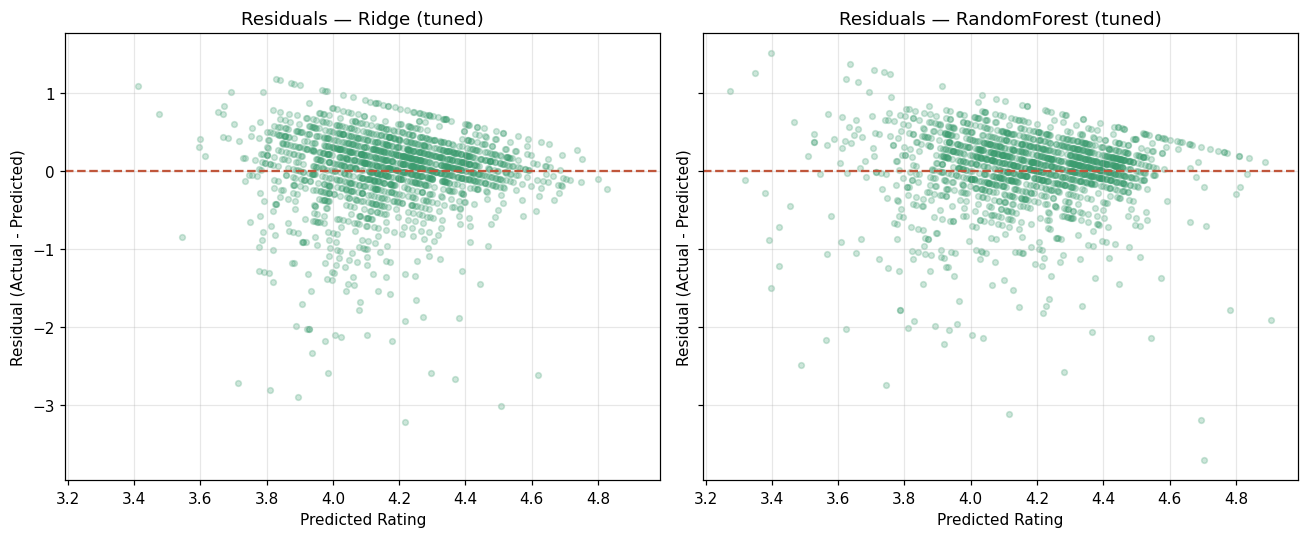

Saved: ../figures/12_residual_plot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, err_col, pred_col, name in zip(
    axes, ["error_ridge", "error_rf"], ["pred_ridge", "pred_rf"], ["Ridge (tuned)", "RandomForest (tuned)"]
):
    ax.scatter(meta_test[pred_col], meta_test[err_col], alpha=0.25, s=14, color="#3b9c6f")
    ax.axhline(0, color="#c0563b", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicted Rating")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(f"Residuals — {name}")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/12_residual_plot.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/12_residual_plot.png")


**Observation.** Residuals are not symmetric around zero across the full
prediction range: for apps predicted around 4.0–4.5 (where most predictions
cluster), residuals scatter fairly evenly above and below zero, but there is a
long tail of large **negative** residuals (actual well below predicted) — these
are the true low-rating apps the model failed to identify, visible as the string
of points trailing down-and-right in both panels.


### 3.3 Residual / Error Distribution

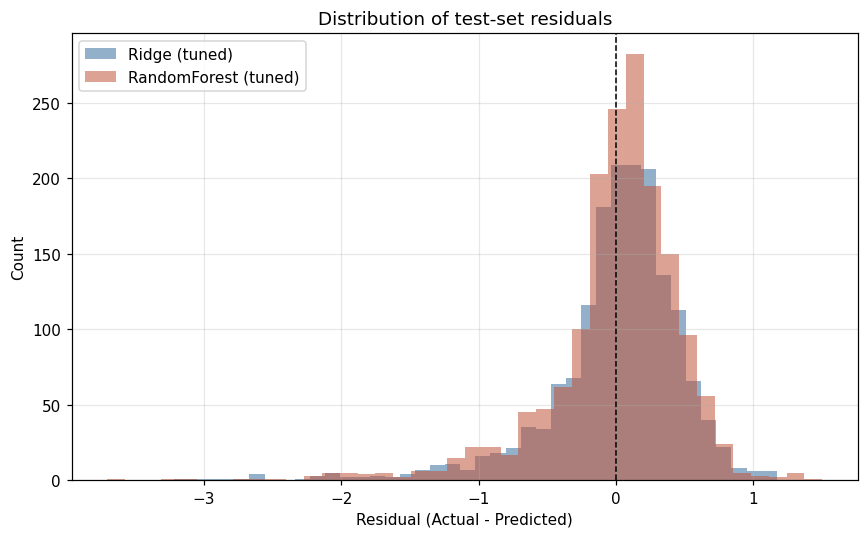

Saved: ../figures/13_error_distribution.png
Residual summary statistics:
       error_ridge     error_rf
count  1640.000000  1640.000000
mean     -0.001566    -0.001657
std       0.506189     0.499119
min      -3.216683    -3.702480
25%      -0.168880    -0.157169
50%       0.068816     0.070563
75%       0.279395     0.282324
max       1.170968     1.502876


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(meta_test["error_ridge"], bins=40, alpha=0.55, label="Ridge (tuned)", color="#3b6fa0")
ax.hist(meta_test["error_rf"], bins=40, alpha=0.55, label="RandomForest (tuned)", color="#c0563b")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
ax.set_title("Distribution of test-set residuals")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/13_error_distribution.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/13_error_distribution.png")

print("Residual summary statistics:")
print(meta_test[["error_ridge", "error_rf"]].describe())


**Observation.** Both residual distributions are centred close to zero and
roughly bell-shaped in the middle, but both show a **left skew** (a longer tail of
large negative residuals) — consistent with the residual plot above. This is the
signature of models that default toward the population mean when they lack
strong per-app signal, then are caught out specifically by the minority of apps
with genuinely low true ratings.


## 4. Feature Importance / Coefficients

### 4.1 RandomForest Feature Importance


In [8]:
rf_feature_names = rf_model.named_steps["prep"].get_feature_names_out()
rf_importances = rf_model.named_steps["model"].feature_importances_

rf_importance_table = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)
rf_importance_table.to_csv(f"{PROCESSED_DIR}/rf_feature_importance.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/rf_feature_importance.csv")
rf_importance_table.head(15)


Saved: ../data/processed/rf_feature_importance.csv


,feature,importance
0,num__log_reviews,0.274150
1,num__days_since_update,0.188311
2,num__Size_MB,0.163813
3,num__log_installs,0.130245
4,num__Price_USD,0.025043
5,cat__Category_TOOLS,0.018755
6,cat__Category_FAMILY,0.015425
7,cat__Category_HEALTH_AND_FITNESS,0.012969
8,cat__Category_LIFESTYLE,0.012523
9,cat__Category_FINANCE,0.010485


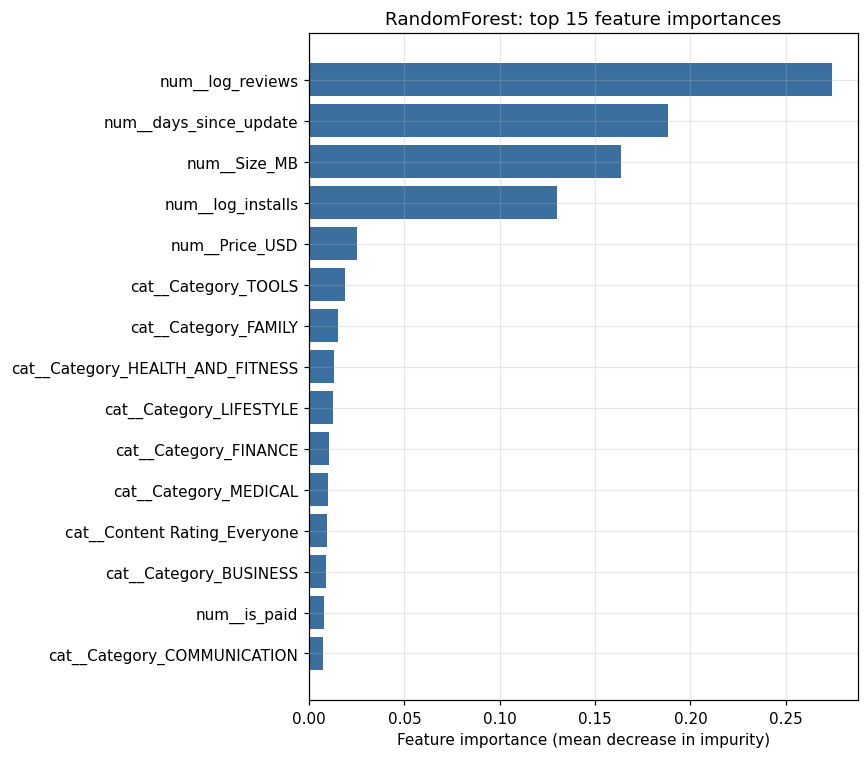

Saved: ../figures/14_rf_feature_importance.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
top15 = rf_importance_table.head(15).iloc[::-1]
ax.barh(top15["feature"], top15["importance"], color="#3b6fa0")
ax.set_xlabel("Feature importance (mean decrease in impurity)")
ax.set_title("RandomForest: top 15 feature importances")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/14_rf_feature_importance.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/14_rf_feature_importance.png")


**Observation.** Four numeric features — `log_reviews`, `days_since_update`,
`Size_MB`, and `log_installs` — dominate RandomForest's importance ranking,
together accounting for the large majority of total importance. Individual
`Category` dummies (`TOOLS`, `FAMILY`, `HEALTH_AND_FITNESS`, `LIFESTYLE`, ...)
contribute small amounts each, consistent with the `f_regression` results in
notebook 03: category matters, but no single category dominates the way review
volume and update recency do.


### 4.2 Ridge Coefficients


In [10]:
ridge_coefs = ridge_model.named_steps["model"].coef_
ridge_feature_names = ridge_model.named_steps["prep"].get_feature_names_out()

ridge_coef_table = pd.DataFrame({
    "feature": ridge_feature_names,
    "coefficient": ridge_coefs,
}).sort_values("coefficient", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
ridge_coef_table.to_csv(f"{PROCESSED_DIR}/ridge_coefficients.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/ridge_coefficients.csv")
ridge_coef_table.head(15)


Saved: ../data/processed/ridge_coefficients.csv


,feature,coefficient
0,num__log_reviews,0.583147
1,num__log_installs,-0.511949
2,cat__Category_PARENTING,0.236759
3,cat__Category_EVENTS,0.227875
4,cat__Category_ART_AND_DESIGN,0.218476
5,cat__Category_BOOKS_AND_REFERENCE,0.172311
6,cat__Category_MAPS_AND_NAVIGATION,-0.160078
7,cat__Category_DATING,-0.150665
8,cat__Category_BEAUTY,0.134041
9,cat__Category_PERSONALIZATION,0.130048


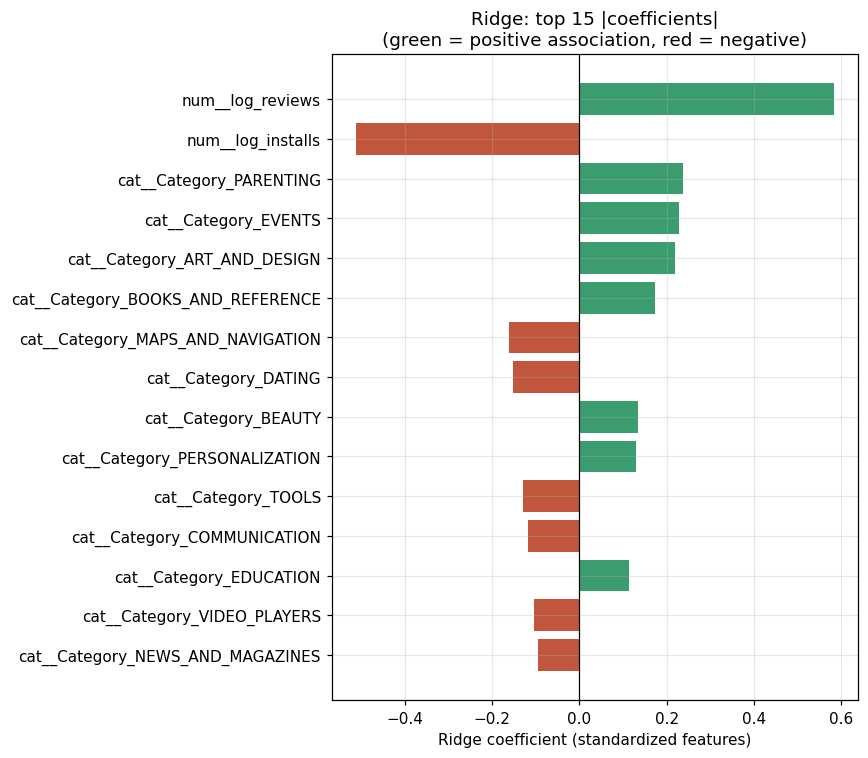

Saved: ../figures/15_ridge_coefficients.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
top15_coef = ridge_coef_table.head(15).iloc[::-1]
colors = ["#3b9c6f" if c > 0 else "#c0563b" for c in top15_coef["coefficient"]]
ax.barh(top15_coef["feature"], top15_coef["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Ridge coefficient (standardized features)")
ax.set_title("Ridge: top 15 |coefficients|\n(green = positive association, red = negative)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/15_ridge_coefficients.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/15_ridge_coefficients.png")


**Observation and an important caveat.** Because numeric features were
standardized before fitting, these coefficients are directly comparable in
magnitude. `log_reviews` has the largest positive coefficient — more-reviewed
apps tend to be rated higher, all else equal. `log_installs`, however, shows a
**negative** coefficient of similar magnitude, which should **not** be read at
face value as "more installs causes lower ratings": `log_reviews` and
`log_installs` are highly correlated (an app rarely has many installs without
also having many reviews), and under this kind of collinearity Ridge can split a
shared positive effect into a large positive and a large negative coefficient
that partially cancel. The RandomForest importance ranking (Section 4.1), which
does not have this sign-splitting issue, shows both `log_reviews` and
`log_installs` contributing positively to prediction — the more trustworthy
reading is "usage volume matters," not "installs specifically hurt ratings."
Beyond these two, several `Category` dummies (`PARENTING`, `EVENTS`,
`ART_AND_DESIGN`, `BOOKS_AND_REFERENCE` positive; `MAPS_AND_NAVIGATION`,
`DATING`, `TOOLS` negative) show modest, more individually interpretable
associations.


## 5. Detailed Error Analysis

Absolute error (`|Actual - Predicted|`) is compared across the subgroups the
faculty asked about. RandomForest (the marginally stronger test-set model) is
used as the primary reference; Ridge is shown alongside for comparison where
useful.


### 5.1 Low-Review Apps


In [12]:
meta_test["Reviews_raw"] = np.expm1(meta_test["log_reviews"]).round().astype(int)
meta_test["Installs_raw"] = np.expm1(meta_test["log_installs"]).round().astype(int)

LOW_REVIEW_THRESHOLD = 100
low_review_mask = meta_test["Reviews_raw"] < LOW_REVIEW_THRESHOLD

low_review_comparison = pd.DataFrame({
    "group": [f"Reviews < {LOW_REVIEW_THRESHOLD}", f"Reviews >= {LOW_REVIEW_THRESHOLD}"],
    "n": [low_review_mask.sum(), (~low_review_mask).sum()],
    "MAE_ridge": [meta_test.loc[low_review_mask, "abs_err_ridge"].mean(),
                  meta_test.loc[~low_review_mask, "abs_err_ridge"].mean()],
    "MAE_rf": [meta_test.loc[low_review_mask, "abs_err_rf"].mean(),
               meta_test.loc[~low_review_mask, "abs_err_rf"].mean()],
})
low_review_comparison


,group,n,MAE_ridge,MAE_rf
0,Reviews < 100,397,0.566206,0.547836
1,Reviews >= 100,1243,0.273942,0.271138


**Finding.** Apps with fewer than 100 reviews have roughly **double** the
prediction error of apps with more reviews, for both models. This matches
intuition: `log_reviews` and `log_installs` (the two strongest predictors) carry
almost no information for apps with little usage history, so the model has
little to go on beyond the population average for these apps.


### 5.2 High-Install Apps


In [13]:
HIGH_INSTALL_THRESHOLD = 1_000_000
high_install_mask = meta_test["Installs_raw"] >= HIGH_INSTALL_THRESHOLD

high_install_comparison = pd.DataFrame({
    "group": [f"Installs >= {HIGH_INSTALL_THRESHOLD:,}", f"Installs < {HIGH_INSTALL_THRESHOLD:,}"],
    "n": [high_install_mask.sum(), (~high_install_mask).sum()],
    "MAE_ridge": [meta_test.loc[high_install_mask, "abs_err_ridge"].mean(),
                  meta_test.loc[~high_install_mask, "abs_err_ridge"].mean()],
    "MAE_rf": [meta_test.loc[high_install_mask, "abs_err_rf"].mean(),
               meta_test.loc[~high_install_mask, "abs_err_rf"].mean()],
})
high_install_comparison


,group,n,MAE_ridge,MAE_rf
0,"Installs >= 1,000,000",680,0.216626,0.210633
1,"Installs < 1,000,000",960,0.435403,0.428422


**Finding.** The pattern mirrors Section 5.1 from the other direction:
high-install apps (≥1,000,000 installs) are predicted noticeably **more
accurately** than lower-install apps. Popular, well-established apps have
converged to a stable rating and rich usage signal, both of which make them
easier to predict; niche/new apps are the hardest cases for this model.


### 5.3 Paid vs. Free Apps


In [14]:
paid_free_comparison = meta_test.groupby("is_paid").agg(
    n=("Rating", "count"),
    MAE_ridge=("abs_err_ridge", "mean"),
    MAE_rf=("abs_err_rf", "mean"),
).rename(index={0: "Free", 1: "Paid"})
paid_free_comparison


,n,MAE_ridge,MAE_rf
is_paid,,,
Free,1525,0.342850,0.336727
Paid,115,0.369109,0.356575


**Finding.** The difference between paid and free apps is small (both
models' errors differ by roughly 0.02–0.03 rating points between groups) —
noticeably smaller than the review-count or install-count effects above.
`is_paid`/`Price_USD` are real but comparatively minor predictors, consistent
with their low ranking in both the RandomForest importance table and the
`f_regression` scores from notebook 03.


### 5.4 By Category


In [15]:
category_error = meta_test.groupby("Category").agg(
    n=("Rating", "count"),
    MAE_rf=("abs_err_rf", "mean"),
    MAE_ridge=("abs_err_ridge", "mean"),
).sort_values("MAE_rf", ascending=False)

print("5 categories with the LARGEST RandomForest error:")
print(category_error.head(5))
print("\n5 categories with the SMALLEST RandomForest error:")
print(category_error.tail(5).sort_values("MAE_rf"))

category_error.to_csv(f"{PROCESSED_DIR}/category_error_analysis.csv")
print("\nSaved:", f"{PROCESSED_DIR}/category_error_analysis.csv")


5 categories with the LARGEST RandomForest error:
                     n    MAE_rf  MAE_ridge
Category                                   
DATING              26  0.646234   0.630415
LIFESTYLE           55  0.511296   0.521327
HEALTH_AND_FITNESS  39  0.465882   0.469650
MEDICAL             71  0.462455   0.460685
BUSINESS            58  0.437647   0.446026

5 categories with the SMALLEST RandomForest error:
                  n    MAE_rf  MAE_ridge
Category                                
EDUCATION        31  0.181808   0.143269
SHOPPING         39  0.216734   0.205633
PERSONALIZATION  54  0.223112   0.234978
HOUSE_AND_HOME   22  0.227924   0.276201
EVENTS           10  0.228438   0.280558

Saved: ../data/processed/category_error_analysis.csv


**Finding.** `DATING`, `LIFESTYLE`, `HEALTH_AND_FITNESS`, `MEDICAL`, and
`BUSINESS` show the largest average errors — categories where user satisfaction
plausibly hinges on factors metadata cannot capture (matching quality in a
dating app, personal health outcomes, professional reliability). `EDUCATION`,
`SHOPPING`, `PERSONALIZATION`, and `GAME` are predicted comparatively well —
larger, more homogeneous categories with more apps and more usage data per app
to learn from (note some small-`n` categories above, e.g. `DATING` with 26 test
apps, should be read with appropriate caution given the small sample).


### 5.5 By Rating Level (Very High vs. Very Low)


In [16]:
bins = [1, 2, 3, 3.5, 4, 4.5, 5.01]
labels = ["1.0-2.0", "2.0-3.0", "3.0-3.5", "3.5-4.0", "4.0-4.5", "4.5-5.0"]
meta_test["rating_bin"] = pd.cut(meta_test["Rating"], bins=bins, labels=labels, right=False)

rating_bin_error = meta_test.groupby("rating_bin", observed=True).agg(
    n=("Rating", "count"),
    MAE_rf=("abs_err_rf", "mean"),
    MAE_ridge=("abs_err_ridge", "mean"),
)
rating_bin_error.to_csv(f"{PROCESSED_DIR}/rating_bin_error_analysis.csv")
print("Saved:", f"{PROCESSED_DIR}/rating_bin_error_analysis.csv")
rating_bin_error


Saved: ../data/processed/rating_bin_error_analysis.csv


,n,MAE_rf,MAE_ridge
rating_bin,,,
1.0-2.0,16,2.370890,2.456294
2.0-3.0,44,1.307523,1.423564
3.0-3.5,78,0.823809,0.808733
3.5-4.0,256,0.326262,0.325300
4.0-4.5,743,0.168640,0.168368
4.5-5.0,503,0.369723,0.381511


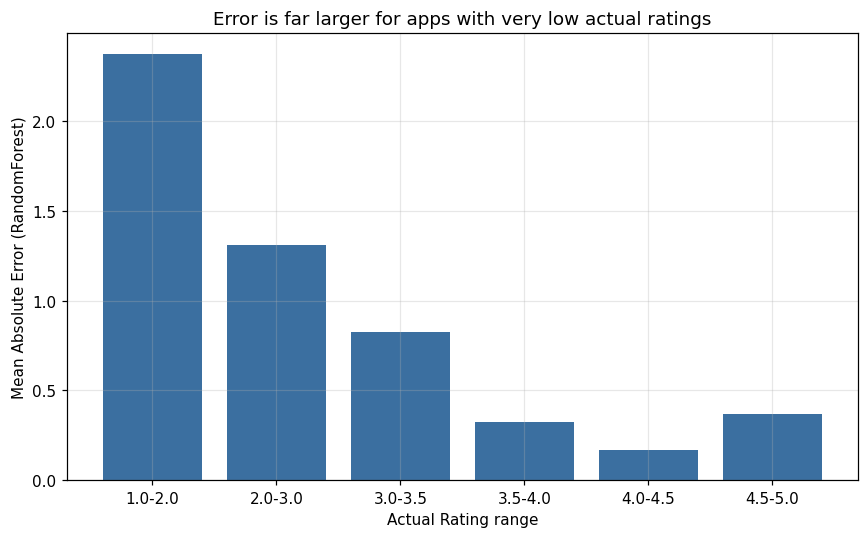

Saved: ../figures/16_error_by_rating_level.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(rating_bin_error.index.astype(str), rating_bin_error["MAE_rf"], color="#3b6fa0")
ax.set_xlabel("Actual Rating range")
ax.set_ylabel("Mean Absolute Error (RandomForest)")
ax.set_title("Error is far larger for apps with very low actual ratings")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/16_error_by_rating_level.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/16_error_by_rating_level.png")


**Finding — the clearest pattern in this analysis.** Error increases sharply
as the true rating moves away from the dataset's dense 4.0–4.5 band. Apps rated
1.0–2.0 have a mean absolute error of **over 2 full rating points** — the model
essentially cannot identify them, because it has learned to predict values close
to the overall mean (~4.17) and has too little distinguishing signal (as shown in
Sections 5.1–5.2, these apps also tend to have very few reviews) to move far
from that default. This is classic regression-to-the-mean behaviour under weak
predictors, and it directly explains why the overall R² is modest even though
the model is clearly using real signal for the bulk of (well-reviewed,
mid-to-high-rated) apps.


## 6. Concrete Examples of Badly Predicted Apps


In [18]:
worst_predictions = meta_test.sort_values("abs_err_rf", ascending=False).head(5)
display_cols = ["App", "Category", "Content Rating", "Rating", "pred_rf", "error_rf",
                 "Reviews_raw", "Installs_raw", "Size_MB", "Price_USD", "days_since_update"]
worst_predictions[display_cols]


,App,Category,Content Rating,Rating,pred_rf,error_rf,Reviews_raw,Installs_raw,Size_MB,Price_USD,days_since_update
434,House party - live chat,DATING,Mature 17+,1.0,4.702480,-3.702480,1,10,9.2,0.00,9
7997,FK Atlantas,SPORTS,Everyone,1.5,4.695076,-3.195076,2,5,26.0,0.00,169
4464,Truck Driving Test Class 3 BC,FAMILY,Everyone,1.0,4.116264,-3.116264,1,50,2.0,1.49,2313
6643,DS Creator 2.0,TOOLS,Everyone,1.0,3.743405,-2.743405,2,500,4.4,0.00,139
4606,BG TV App,FAMILY,Everyone,1.7,4.280230,-2.580230,6,100,2.9,0.00,231


**Example 1 — "House party - live chat" (`DATING`).**
Actual rating **1.0**, predicted **4.70** (error −3.70). This app has just **1
review** and **10 installs** — essentially no usage history for the model to
learn from — and belongs to `DATING`, the category with the worst average error
in Section 5.4. With almost no informative signal available, the model falls
back close to the population mean; the true rating of 1.0 likely reflects a
specific bad first-use experience (a crash, a broken feature, a scam concern —
none of which appear anywhere in this dataset's metadata).

**Example 2 — "FK Atlantas" (`SPORTS`).**
Actual rating **1.5**, predicted **4.70** (error −3.20). Again, only **2
reviews** and **5 installs** in total. The model has no way to distinguish this
essentially-unused app from any other `SPORTS` app with unknown quality, so it
again predicts close to the overall average. Both examples illustrate the same
underlying limitation identified throughout this section: **the fewer reviews an
app has, the less the available metadata can tell the model about its true
quality**, and the model's fallback-to-average behaviour is precisely what
produces the largest individual errors.


## 7. Answers to the Three Approved Research Questions

Answered directly, using evidence gathered across notebooks 01, 03, 04, and this
notebook.


### RQ1: Which app characteristics are most strongly associated with Google
Play Store ratings?

**Answer.** Review volume and update recency are the two strongest associations
by a clear margin. `log_reviews` is the single strongest predictor in every
analysis run in this project — the top-scoring feature in the `f_regression`
pass in notebook 03 (F=225.9), the top RandomForest importance (0.274, Section
4.1), and the largest-magnitude Ridge coefficient (Section 4.2). `days_since_update`
is consistently the second-strongest signal (F=95.2 in notebook 03; second-highest
RandomForest importance at 0.188) — more recently updated apps tend to be rated
higher. `log_installs` and `Size_MB` are moderately important
(RandomForest importance 0.130 and 0.164 respectively). `Category` matters, but
diffusely — no single category dominates; instead, many individual categories
(`TOOLS`, `FAMILY`, `HEALTH_AND_FITNESS`, `PARENTING`, `EVENTS`, and others)
each contribute a small amount. `Price`/`is_paid` show the weakest, though still
statistically detectable, association (Section 5.3; low RandomForest importance).
The dating/lifestyle/health/medical/business categories are where these
characteristics explain the *least* (Section 5.4), suggesting rating in those
categories depends more on factors outside this dataset (see RQ2/Section 8 of
the report).


In [19]:
rq1_evidence = pd.concat([
    rf_importance_table.head(6).assign(source="RF importance"),
], ignore_index=True)[["source", "feature", "importance"]]
rq1_evidence


,source,feature,importance
0,RF importance,num__log_reviews,0.274150
1,RF importance,num__days_since_update,0.188311
2,RF importance,num__Size_MB,0.163813
3,RF importance,num__log_installs,0.130245
4,RF importance,num__Price_USD,0.025043
5,RF importance,cat__Category_TOOLS,0.018755


### RQ2: How accurately can machine-learning regression models predict an
application's rating using its available characteristics?

**Answer.** Modestly, but measurably better than a naive baseline. The tuned
RandomForest achieves test-set **R² = 0.164**, tuned Ridge achieves **R² =
0.140** — both clearly above the Dummy baseline's R² ≈ 0 (Section 2). In
absolute terms, the tuned models' **MAE is ≈0.34–0.35 rating points** and
**RMSE is ≈0.50–0.51 rating points** on a 1–5 star scale, versus the Dummy
baseline's MAE ≈0.38 / RMSE ≈0.55. This is a real, if modest, improvement: the
models are typically off by roughly a third of a star, and are considerably more
accurate for well-reviewed, high-install apps than for niche or barely-used
apps (Section 5). The honest overall answer is: **app metadata alone predicts
`Rating` only weakly — accurately enough to be informative about broad
tendencies (more reviews/recent updates associate with higher ratings), but far
from precisely enough to predict an individual app's exact rating**, especially
at the rating extremes (Section 5.5).


### RQ3: Which machine-learning model and feature set provides the best
rating-prediction performance after preprocessing, feature selection,
dimensionality reduction, and hyperparameter tuning?

**Answer.** The **tuned RandomForestRegressor**, using the **full engineered
feature space** (6 numeric + one-hot encoded `Category`/`Content Rating`, 45
dimensions after encoding), gives the best test-set performance (R²=0.164,
MAE=0.338, RMSE=0.499), narrowly ahead of tuned Ridge (R²=0.140, MAE=0.345,
RMSE=0.506) — see Section 2. Both PCA and `f_regression`-based feature
selection were tested via cross-validation in notebook 04, Section 4, and **both
reduced performance relative to the full feature space** (PCA especially so:
Ridge R² dropped from 0.147 to 0.048), so neither is part of the best-performing
configuration. The best RandomForest hyperparameters found by
`RandomizedSearchCV` were `n_estimators=200, max_depth=None, min_samples_split=10,
min_samples_leaf=2, max_features=0.5` (notebook 04, Section 7.3). That said, the
margin between RandomForest and Ridge is narrow enough — and the CV standard
deviations reported in notebook 04 overlap enough — that this should be read as
"RandomForest and Ridge extract a broadly similar, modest amount of signal from
this feature set," with RandomForest's flexibility giving it a small, consistent
edge, rather than as one model family being decisively correct for this problem.


## 8. Interpretation of R² — Why This Result Is Expected, Not a Failure

The observed test R² (0.140 for Ridge, 0.164 for RandomForest) sits at, or just
above, the faculty's expected **0.05–0.15** range for this task. This is
interpreted here honestly, as the anticipated outcome of a task with a genuinely
weak predictive ceiling — not adjusted, hidden, or apologised for.

**Why app metadata cannot fully explain a subjective rating.** `Rating` is an
aggregate of many individual users' subjective satisfaction judgements. The
features available in this dataset — category, review/install counts, size,
price, update recency, content rating — describe an app's *listing*, not its
*lived user experience*. None of the following, all of which plausibly drive how
a real user rates an app, are present anywhere in this data:

- **Actual functional quality**: bugs, crashes, load times, battery drain.
- **User experience design**: how intuitive, polished, or frustrating the app
  feels to use.
- **Advertising load**: how many/how intrusive the ads are (a very common
  complaint driver in app reviews).
- **Developer responsiveness**: whether bug reports and complaints get fixed.
- **Evolving user expectations**: what "good" means shifts over an app's
  lifetime and across categories.
- **Privacy/data-handling concerns**: a significant driver of 1-star reviews in
  some categories (e.g. `DATING`, `FINANCE`, `HEALTH_AND_FITNESS` — notably
  among the categories with the largest prediction error in Section 5.4).

Given this, an R² of roughly 0.05–0.16 is not a sign that the modelling was done
incorrectly — it is close to the ceiling of what *should* be achievable from
metadata alone. The error analysis in Section 5 supports this reading directly:
the model predicts well precisely where it has rich behavioural signal
(high-review, high-install apps) and fails precisely where that signal is
absent (low-review apps, and apps in categories where subjective experience
plausibly dominates). The right conclusion is not "the model failed," but
**"app metadata carries a real, small, identifiable signal about `Rating`, and
the great majority of what determines a user's rating is not captured by this
dataset."**


## 9. Why This Project Remains a Regression Task

The faculty's proposal allowed a documented switch to a binary
`high_rating = 1 if Rating > 4.3` classification task **only if regression
became genuinely uninformative**. That condition is not met here:

- Both tuned models beat the Dummy baseline by a clear, consistent margin on
  every metric, in both cross-validation (notebook 04) and on the untouched
  test set (Section 2) — this is the opposite of "uninformative."
- The signal found is **directionally sensible and consistent across three
  independent methods** (correlation in notebook 01, `f_regression` in notebook
  03, RandomForest importance and Ridge coefficients in this notebook), which
  would not be expected from noise.
- The error analysis in Section 5 produced **interpretable, actionable
  findings** (errors concentrate in low-review apps and at rating extremes)
  that a regression framing surfaces naturally and a coarser binary label would
  obscure.

Regression therefore remains the appropriate framing, exactly as documented from
the start, and the observed R² is reported as the honest, if modest, result of
that framing — not as a reason to change the task after the fact.
